<a href="https://colab.research.google.com/github/kushalaralpati/fintech-funnel-intelligence/blob/main/fintech_signup_dropoff_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fintech Sign-Up Drop-Off ETL Pipeline (Colab)

Synthetic fintech onboarding events -> **PostgreSQL** -> 18 engineered behavioural
features -> **XGBoost** drop-off classifier.

This notebook is fully self-contained: it installs PostgreSQL *inside this
Colab VM*, writes out the pipeline's source files, and runs
generate -> ingest -> feature-engineer -> train end to end.

**Note:** Postgres here lives only in this VM's disk. Data does **not**
persist once the Colab runtime is recycled/disconnected. Re-run the cells
top to bottom on a fresh runtime.

Run all cells in order: **Runtime -> Run all**.

## 1. Install & start PostgreSQL in this VM

In [1]:
!apt-get -y -qq update
!apt-get -y -qq install postgresql > /dev/null
!service postgresql start
!sudo -u postgres psql -c "ALTER USER postgres PASSWORD 'postgres';"
!sudo -u postgres psql -c "SELECT 1 FROM pg_database WHERE datname = 'fintech_signup'" | grep -q 1 || \
  sudo -u postgres psql -c "CREATE DATABASE fintech_signup;"
!sudo -u postgres psql -d fintech_signup -c "\dt"


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
 * Starting PostgreSQL 14 database server
   ...done.
ALTER ROLE
CREATE DATABASE
Did not find any relations.


## 2. Install Python dependencies

In [2]:
!pip install -q psycopg2-binary SQLAlchemy pandas numpy scikit-learn xgboost joblib matplotlib python-dotenv


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 13.2 MB/s eta 0:00:00


## 3. Write out the pipeline source files
Same code as the standalone project (`fintech_signup_etl/`), written here so the notebook is self-contained.

In [3]:
import os
os.makedirs("/content/fintech_signup_etl/src", exist_ok=True)
os.makedirs("/content/fintech_signup_etl/sql", exist_ok=True)
os.makedirs("/content/fintech_signup_etl/artifacts", exist_ok=True)


In [4]:
%%writefile /content/fintech_signup_etl/sql/schema.sql
-- Raw, append-only event stream from the sign-up funnel.
-- One row per tracked client/server event.
CREATE TABLE IF NOT EXISTS raw_signup_events (
    event_id            BIGSERIAL PRIMARY KEY,
    user_id             UUID        NOT NULL,
    session_id          UUID        NOT NULL,
    event_name          TEXT        NOT NULL,
    event_ts            TIMESTAMPTZ NOT NULL,
    device_type         TEXT        NOT NULL,   -- mobile | desktop | tablet
    os                  TEXT        NOT NULL,
    browser             TEXT        NOT NULL,
    referral_source     TEXT        NOT NULL,   -- organic | paid_search | social | affiliate | direct
    marketing_channel   TEXT        NOT NULL,   -- brand | performance | referral | none
    ip_country          TEXT        NOT NULL,
    metadata            JSONB       NOT NULL DEFAULT '{}'::jsonb,
    ingested_at         TIMESTAMPTZ NOT NULL DEFAULT now()
);

CREATE INDEX IF NOT EXISTS idx_raw_signup_events_user_id  ON raw_signup_events (user_id);
CREATE INDEX IF NOT EXISTS idx_raw_signup_events_ts       ON raw_signup_events (event_ts);
CREATE INDEX IF NOT EXISTS idx_raw_signup_events_name     ON raw_signup_events (event_name);
CREATE INDEX IF NOT EXISTS idx_raw_signup_events_user_ts  ON raw_signup_events (user_id, event_ts);

-- One row per user: 18 engineered behavioural features + drop-off label.
-- Rebuilt by src/features.py on every pipeline run.
CREATE TABLE IF NOT EXISTS user_features (
    user_id                          UUID PRIMARY KEY,

    total_events                     INTEGER     NOT NULL,
    num_sessions                     INTEGER     NOT NULL,
    total_duration_sec               DOUBLE PRECISION NOT NULL,
    avg_time_between_events_sec      DOUBLE PRECISION NOT NULL,
    median_time_between_events_sec   DOUBLE PRECISION NOT NULL,
    max_time_gap_sec                 DOUBLE PRECISION NOT NULL,
    time_to_first_step_sec           DOUBLE PRECISION NOT NULL,
    num_form_errors                  INTEGER     NOT NULL,
    num_otp_retries                  INTEGER     NOT NULL,
    num_backtrack_events             INTEGER     NOT NULL,
    num_help_clicks                  INTEGER     NOT NULL,
    num_device_switches              INTEGER     NOT NULL,
    is_mobile_majority                SMALLINT   NOT NULL,
    completed_email_verification     SMALLINT    NOT NULL,
    completed_phone_verification     SMALLINT    NOT NULL,
    completed_kyc_upload             SMALLINT    NOT NULL,
    completed_bank_link              SMALLINT    NOT NULL,
    hour_of_day_started              SMALLINT    NOT NULL,

    dropped_off                      SMALLINT    NOT NULL,  -- label: 1 = did not finish funnel
    computed_at                      TIMESTAMPTZ NOT NULL DEFAULT now()
);


Writing /content/fintech_signup_etl/sql/schema.sql


In [5]:
%%writefile /content/fintech_signup_etl/sql/feature_engineering.sql
-- Builds the 18 behavioural features (+ drop-off label) per user from
-- raw_signup_events and (re)populates user_features. Safe to re-run.

WITH ordered_events AS (
    SELECT
        user_id,
        event_ts,
        EXTRACT(EPOCH FROM (
            event_ts - LAG(event_ts) OVER (PARTITION BY user_id ORDER BY event_ts)
        )) AS gap_sec
    FROM raw_signup_events
),
gap_stats AS (
    SELECT
        user_id,
        AVG(gap_sec)                                            AS avg_gap,
        PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY gap_sec)     AS median_gap,
        MAX(gap_sec)                                             AS max_gap
    FROM ordered_events
    WHERE gap_sec IS NOT NULL
    GROUP BY user_id
),
device_counts AS (
    SELECT user_id, device_type, COUNT(*) AS cnt
    FROM raw_signup_events
    GROUP BY user_id, device_type
),
device_mode AS (
    -- majority (most-used) device per user; ties broken deterministically by device name
    SELECT DISTINCT ON (user_id) user_id, device_type AS majority_device
    FROM device_counts
    ORDER BY user_id, cnt DESC, device_type
),
base AS (
    SELECT
        user_id,
        COUNT(*)                                                             AS total_events,
        COUNT(DISTINCT session_id)                                           AS num_sessions,
        EXTRACT(EPOCH FROM (MAX(event_ts) - MIN(event_ts)))                  AS total_duration_sec,
        MIN(event_ts)                                                        AS first_event_ts,
        MIN(event_ts) FILTER (WHERE event_name = 'landing_page_view')        AS landing_ts,
        MIN(event_ts) FILTER (WHERE event_name = 'signup_started')           AS signup_started_ts,
        COUNT(*) FILTER (WHERE event_name = 'form_error')                    AS num_form_errors,
        COUNT(*) FILTER (WHERE event_name = 'otp_retry')                     AS num_otp_retries,
        COUNT(*) FILTER (WHERE event_name = 'back_navigation')               AS num_backtrack_events,
        COUNT(*) FILTER (WHERE event_name = 'help_click')                    AS num_help_clicks,
        COUNT(*) FILTER (WHERE event_name = 'device_switch')                 AS num_device_switches,
        MAX(CASE WHEN event_name = 'email_verified' THEN 1 ELSE 0 END)             AS completed_email_verification,
        MAX(CASE WHEN event_name = 'otp_verified' THEN 1 ELSE 0 END)               AS completed_phone_verification,
        MAX(CASE WHEN event_name = 'kyc_document_uploaded' THEN 1 ELSE 0 END)      AS completed_kyc_upload,
        MAX(CASE WHEN event_name = 'bank_account_linked' THEN 1 ELSE 0 END)        AS completed_bank_link,
        MAX(CASE WHEN event_name = 'first_transaction_completed' THEN 1 ELSE 0 END) AS completed_signup
    FROM raw_signup_events
    GROUP BY user_id
)
INSERT INTO user_features (
    user_id, total_events, num_sessions, total_duration_sec,
    avg_time_between_events_sec, median_time_between_events_sec, max_time_gap_sec,
    time_to_first_step_sec, num_form_errors, num_otp_retries, num_backtrack_events,
    num_help_clicks, num_device_switches, is_mobile_majority,
    completed_email_verification, completed_phone_verification,
    completed_kyc_upload, completed_bank_link, hour_of_day_started, dropped_off
)
SELECT
    b.user_id,
    b.total_events,
    b.num_sessions,
    b.total_duration_sec,
    COALESCE(g.avg_gap, 0),
    COALESCE(g.median_gap, 0),
    COALESCE(g.max_gap, 0),
    COALESCE(EXTRACT(EPOCH FROM (b.signup_started_ts - b.landing_ts)), 0) AS time_to_first_step_sec,
    b.num_form_errors,
    b.num_otp_retries,
    b.num_backtrack_events,
    b.num_help_clicks,
    b.num_device_switches,
    CASE WHEN dm.majority_device = 'mobile' THEN 1 ELSE 0 END              AS is_mobile_majority,
    b.completed_email_verification,
    b.completed_phone_verification,
    b.completed_kyc_upload,
    b.completed_bank_link,
    EXTRACT(HOUR FROM b.first_event_ts)::smallint                          AS hour_of_day_started,
    CASE WHEN b.completed_signup = 1 THEN 0 ELSE 1 END                    AS dropped_off
FROM base b
LEFT JOIN gap_stats g ON g.user_id = b.user_id
LEFT JOIN device_mode dm ON dm.user_id = b.user_id
ON CONFLICT (user_id) DO UPDATE SET
    total_events                    = EXCLUDED.total_events,
    num_sessions                    = EXCLUDED.num_sessions,
    total_duration_sec              = EXCLUDED.total_duration_sec,
    avg_time_between_events_sec     = EXCLUDED.avg_time_between_events_sec,
    median_time_between_events_sec  = EXCLUDED.median_time_between_events_sec,
    max_time_gap_sec                = EXCLUDED.max_time_gap_sec,
    time_to_first_step_sec          = EXCLUDED.time_to_first_step_sec,
    num_form_errors                 = EXCLUDED.num_form_errors,
    num_otp_retries                 = EXCLUDED.num_otp_retries,
    num_backtrack_events            = EXCLUDED.num_backtrack_events,
    num_help_clicks                 = EXCLUDED.num_help_clicks,
    num_device_switches             = EXCLUDED.num_device_switches,
    is_mobile_majority              = EXCLUDED.is_mobile_majority,
    completed_email_verification    = EXCLUDED.completed_email_verification,
    completed_phone_verification    = EXCLUDED.completed_phone_verification,
    completed_kyc_upload            = EXCLUDED.completed_kyc_upload,
    completed_bank_link             = EXCLUDED.completed_bank_link,
    hour_of_day_started             = EXCLUDED.hour_of_day_started,
    dropped_off                     = EXCLUDED.dropped_off,
    computed_at                     = now();


Writing /content/fintech_signup_etl/sql/feature_engineering.sql


In [6]:
%%writefile /content/fintech_signup_etl/src/__init__.py


Writing /content/fintech_signup_etl/src/__init__.py


In [7]:
%%writefile /content/fintech_signup_etl/src/config.py
"""Central configuration, read from environment variables (optionally via a .env file)."""
from __future__ import annotations

import os
from dataclasses import dataclass
from pathlib import Path

from dotenv import load_dotenv

ROOT_DIR = Path(__file__).resolve().parent.parent
load_dotenv(ROOT_DIR / ".env")


@dataclass(frozen=True)
class Settings:
    pg_host: str = os.getenv("PGHOST", "localhost")
    pg_port: int = int(os.getenv("PGPORT", "5432"))
    pg_database: str = os.getenv("PGDATABASE", "fintech_signup")
    pg_user: str = os.getenv("PGUSER", "postgres")
    pg_password: str = os.getenv("PGPASSWORD", "postgres")

    n_users: int = int(os.getenv("SIGNUP_N_USERS", "20000"))
    random_seed: int = int(os.getenv("SIGNUP_RANDOM_SEED", "42"))

    @property
    def sqlalchemy_url(self) -> str:
        return (
            f"postgresql+psycopg2://{self.pg_user}:{self.pg_password}"
            f"@{self.pg_host}:{self.pg_port}/{self.pg_database}"
        )


settings = Settings()


Writing /content/fintech_signup_etl/src/config.py


In [8]:
%%writefile /content/fintech_signup_etl/src/db.py
"""SQLAlchemy engine and small schema/DDL helpers."""
from __future__ import annotations

from pathlib import Path

from sqlalchemy import Engine, create_engine, text

from .config import ROOT_DIR, settings

SCHEMA_SQL_PATH = ROOT_DIR / "sql" / "schema.sql"
FEATURES_SQL_PATH = ROOT_DIR / "sql" / "feature_engineering.sql"

_engine: Engine | None = None


def get_engine() -> Engine:
    global _engine
    if _engine is None:
        _engine = create_engine(settings.sqlalchemy_url, pool_pre_ping=True)
    return _engine


def run_sql_file(path: Path) -> None:
    sql_text = path.read_text(encoding="utf-8")
    with get_engine().begin() as conn:
        conn.execute(text(sql_text))


def ensure_schema() -> None:
    run_sql_file(SCHEMA_SQL_PATH)


def truncate_events() -> None:
    with get_engine().begin() as conn:
        conn.execute(text("TRUNCATE TABLE raw_signup_events RESTART IDENTITY"))


def truncate_features() -> None:
    with get_engine().begin() as conn:
        conn.execute(text("TRUNCATE TABLE user_features"))


Writing /content/fintech_signup_etl/src/db.py


In [9]:
%%writefile /content/fintech_signup_etl/src/data_generator.py
"""
Synthetic fintech sign-up funnel event generator.

Simulates a realistic onboarding funnel (landing -> KYC -> funded account ->
first transaction) as a raw clickstream/event-log, the same shape a real
product-analytics pipeline (Segment/Amplitude/Snowplow -> warehouse) would
produce. Each user is given a latent "engagement" score that drives both
step-to-step conversion and friction (errors, retries, long idle gaps), so
the resulting event log carries a genuinely learnable drop-off signal
without hard-coding the label into any single feature.
"""
from __future__ import annotations

import uuid
from dataclasses import dataclass, field
from datetime import datetime, timedelta, timezone
from typing import Any

import numpy as np
import pandas as pd

FUNNEL_STEPS: list[str] = [
    "landing_page_view",
    "signup_started",
    "email_submitted",
    "email_verified",
    "phone_number_submitted",
    "otp_sent",
    "otp_verified",
    "personal_info_submitted",
    "kyc_document_uploaded",
    "kyc_approved",
    "bank_account_linked",
    "funding_source_added",
    "first_transaction_completed",
]

# P(advance to next step | engagement == 0.5, no friction)
BASE_ADVANCE_PROB: dict[str, float] = {
    "landing_page_view": 0.62,
    "signup_started": 0.88,
    "email_submitted": 0.85,
    "email_verified": 0.88,
    "phone_number_submitted": 0.95,
    "otp_sent": 0.85,
    "otp_verified": 0.90,
    "personal_info_submitted": 0.80,
    "kyc_document_uploaded": 0.88,
    "kyc_approved": 0.82,
    "bank_account_linked": 0.85,
    "funding_source_added": 0.85,
}

STEPS_WITH_ERROR_RISK = {
    "email_submitted", "phone_number_submitted", "personal_info_submitted",
    "kyc_document_uploaded",
}

DEVICE_TYPES = ["mobile", "desktop", "tablet"]
DEVICE_WEIGHTS = [0.60, 0.34, 0.06]

OS_BY_DEVICE = {
    "mobile": (["iOS", "Android"], [0.5, 0.5]),
    "tablet": (["iPadOS", "Android"], [0.7, 0.3]),
    "desktop": (["Windows", "macOS", "Linux"], [0.62, 0.32, 0.06]),
}
BROWSER_BY_DEVICE = {
    "mobile": (["Safari", "Chrome", "Samsung Internet"], [0.45, 0.45, 0.10]),
    "tablet": (["Safari", "Chrome"], [0.6, 0.4]),
    "desktop": (["Chrome", "Safari", "Edge", "Firefox"], [0.55, 0.18, 0.15, 0.12]),
}

REFERRAL_SOURCES = ["organic", "paid_search", "social", "affiliate", "direct"]
REFERRAL_WEIGHTS = [0.28, 0.22, 0.18, 0.12, 0.20]
# additive shift applied to the latent engagement score, by acquisition channel
REFERRAL_ENGAGEMENT_SHIFT = {
    "organic": 0.06, "direct": 0.08, "affiliate": 0.0,
    "social": -0.05, "paid_search": -0.07,
}

MARKETING_CHANNELS = ["brand", "performance", "referral", "none"]
MARKETING_WEIGHTS = [0.25, 0.35, 0.15, 0.25]

COUNTRIES = ["US", "GB", "CA", "AU", "DE", "IN", "SG"]
COUNTRY_WEIGHTS = [0.42, 0.14, 0.10, 0.08, 0.10, 0.10, 0.06]

# 24 hourly traffic weights, peaks around mid-morning, lunch and evening
HOUR_WEIGHTS = np.array([
    0.010, 0.006, 0.004, 0.003, 0.004, 0.008, 0.018, 0.032,
    0.050, 0.062, 0.060, 0.052, 0.058, 0.055, 0.045, 0.040,
    0.038, 0.042, 0.055, 0.068, 0.070, 0.060, 0.038, 0.022,
])
HOUR_WEIGHTS = HOUR_WEIGHTS / HOUR_WEIGHTS.sum()

WINDOW_DAYS = 90


def _sigmoid(x: float) -> float:
    return 1.0 / (1.0 + np.exp(-x))


def _logit(p: float) -> float:
    p = min(max(p, 1e-6), 1 - 1e-6)
    return float(np.log(p / (1 - p)))


def _sample_categorical(rng: np.random.Generator, options: list[str], weights: list[float]) -> str:
    return options[rng.choice(len(options), p=weights)]


@dataclass
class UserContext:
    user_id: str
    engagement: float
    device_type: str
    os: str
    browser: str
    referral_source: str
    marketing_channel: str
    ip_country: str
    session_id: str
    events: list[dict[str, Any]] = field(default_factory=list)


def _new_session_id() -> str:
    return str(uuid.uuid4())


def _sample_start_timestamp(rng: np.random.Generator, now: datetime) -> datetime:
    day_offset = rng.integers(0, WINDOW_DAYS)
    hour = rng.choice(24, p=HOUR_WEIGHTS)
    minute = rng.integers(0, 60)
    second = rng.integers(0, 60)
    day = now - timedelta(days=int(day_offset))
    return day.replace(hour=int(hour), minute=int(minute), second=int(second), microsecond=0)


def _sample_gap_seconds(rng: np.random.Generator, engagement: float) -> float:
    """Time to the next in-funnel event. Lower engagement -> longer, heavier-tailed gaps."""
    base_mean = 25 + (1 - engagement) * 90  # seconds
    gap = rng.lognormal(mean=np.log(base_mean), sigma=0.9)
    # occasional "walked away and came back" long gap, more likely for low-engagement users
    if rng.random() < (0.03 + (1 - engagement) * 0.10):
        gap += rng.uniform(1800, 3 * 3600)  # 30 min - 3 hr
    return float(gap)


def _emit(ctx: UserContext, event_name: str, ts: datetime, **metadata: Any) -> None:
    ctx.events.append({
        "user_id": ctx.user_id,
        "session_id": ctx.session_id,
        "event_name": event_name,
        "event_ts": ts,
        "device_type": ctx.device_type,
        "os": ctx.os,
        "browser": ctx.browser,
        "referral_source": ctx.referral_source,
        "marketing_channel": ctx.marketing_channel,
        "ip_country": ctx.ip_country,
        "metadata": metadata,
    })


def _maybe_switch_device(rng: np.random.Generator, ctx: UserContext, ts: datetime) -> datetime:
    if rng.random() < 0.03:
        old_device = ctx.device_type
        remaining = [d for d in DEVICE_TYPES if d != old_device]
        ctx.device_type = rng.choice(remaining)
        oss, oss_w = OS_BY_DEVICE[ctx.device_type]
        ctx.os = _sample_categorical(rng, oss, oss_w)
        browsers, browsers_w = BROWSER_BY_DEVICE[ctx.device_type]
        ctx.browser = _sample_categorical(rng, browsers, browsers_w)
        ctx.session_id = _new_session_id()
        ts = ts + timedelta(seconds=_sample_gap_seconds(rng, ctx.engagement) + rng.uniform(600, 7200))
        _emit(ctx, "device_switch", ts, from_device=old_device, to_device=ctx.device_type)
    return ts


def generate_user_events(rng: np.random.Generator, now: datetime) -> list[dict[str, Any]]:
    user_id = str(uuid.uuid4())

    device_type = _sample_categorical(rng, DEVICE_TYPES, DEVICE_WEIGHTS)
    oss, oss_w = OS_BY_DEVICE[device_type]
    browsers, browsers_w = BROWSER_BY_DEVICE[device_type]
    referral_source = _sample_categorical(rng, REFERRAL_SOURCES, REFERRAL_WEIGHTS)

    # latent engagement score in [0, 1]: mixture of a low- and high-intent population
    if rng.random() < 0.45:
        engagement = rng.beta(2.2, 4.5)
    else:
        engagement = rng.beta(4.5, 2.2)
    engagement = float(np.clip(engagement + REFERRAL_ENGAGEMENT_SHIFT[referral_source], 0.02, 0.98))

    ctx = UserContext(
        user_id=user_id,
        engagement=engagement,
        device_type=device_type,
        os=_sample_categorical(rng, oss, oss_w),
        browser=_sample_categorical(rng, browsers, browsers_w),
        referral_source=referral_source,
        marketing_channel=_sample_categorical(rng, MARKETING_CHANNELS, MARKETING_WEIGHTS),
        ip_country=_sample_categorical(rng, COUNTRIES, COUNTRY_WEIGHTS),
        session_id=_new_session_id(),
    )

    ts = _sample_start_timestamp(rng, now)
    friction = 0.0  # accumulated errors/retries that make the *next* step less likely

    # pre-signup hesitation: extra page views / help clicks for low-engagement users
    n_hesitation_events = rng.poisson(lam=max(0.0, (1 - ctx.engagement) * 1.8))
    for _ in range(n_hesitation_events):
        ts = ts + timedelta(seconds=_sample_gap_seconds(rng, ctx.engagement))
        _emit(ctx, rng.choice(["page_view", "help_click"], p=[0.75, 0.25]), ts)

    if n_hesitation_events:
        ts = ts + timedelta(seconds=float(rng.uniform(1, 5)))
    _emit(ctx, FUNNEL_STEPS[0], ts)

    for step, next_step in zip(FUNNEL_STEPS[:-1], FUNNEL_STEPS[1:]):
        base_p = BASE_ADVANCE_PROB[step]
        advance_logit = _logit(base_p) + 2.6 * (ctx.engagement - 0.5) - 0.35 * friction
        advance_p = _sigmoid(advance_logit)

        if step in STEPS_WITH_ERROR_RISK:
            error_p = 0.10 + (1 - ctx.engagement) * 0.35
            n_errors = rng.binomial(2, min(error_p, 0.9))
            for _ in range(n_errors):
                ts = ts + timedelta(seconds=_sample_gap_seconds(rng, ctx.engagement) * 0.4)
                _emit(ctx, "form_error", ts, step=step)
                friction += 0.5

        if step == "otp_sent":
            retry_p = 0.08 + (1 - ctx.engagement) * 0.30
            n_retries = rng.binomial(3, min(retry_p, 0.9))
            for _ in range(n_retries):
                ts = ts + timedelta(seconds=_sample_gap_seconds(rng, ctx.engagement) * 0.3)
                _emit(ctx, "otp_retry", ts)
                friction += 0.4

        if rng.random() < (0.02 + (1 - ctx.engagement) * 0.05):
            ts = ts + timedelta(seconds=_sample_gap_seconds(rng, ctx.engagement) * 0.2)
            _emit(ctx, "back_navigation", ts, at_step=step)
            friction += 0.15

        if rng.random() < (0.015 + (1 - ctx.engagement) * 0.03):
            ts = ts + timedelta(seconds=_sample_gap_seconds(rng, ctx.engagement) * 0.2)
            _emit(ctx, "help_click", ts, at_step=step)

        ts = _maybe_switch_device(rng, ctx, ts)

        if rng.random() >= advance_p:
            break  # user dropped off between `step` and `next_step`

        gap = _sample_gap_seconds(rng, ctx.engagement)
        if gap > 1800 and rng.random() < 0.5:
            ctx.session_id = _new_session_id()  # came back later -> new session
        ts = ts + timedelta(seconds=gap)
        friction = max(0.0, friction - 0.2)  # frustration fades a little between steps
        _emit(ctx, next_step, ts)

    return ctx.events


def generate_events(n_users: int, seed: int) -> pd.DataFrame:
    """Generate a full synthetic sign-up event log for `n_users` users."""
    rng = np.random.default_rng(seed)
    now = datetime.now(timezone.utc)

    all_events: list[dict[str, Any]] = []
    for _ in range(n_users):
        all_events.extend(generate_user_events(rng, now))

    df = pd.DataFrame(all_events)
    df = df.sort_values(["user_id", "event_ts"], kind="stable").reset_index(drop=True)
    return df


Writing /content/fintech_signup_etl/src/data_generator.py


In [10]:
%%writefile /content/fintech_signup_etl/src/ingest.py
"""Load a synthetic sign-up event log into Postgres (raw_signup_events)."""
from __future__ import annotations

import json
import logging

import pandas as pd
from sqlalchemy import text

from .data_generator import generate_events
from .db import ensure_schema, get_engine, truncate_events
from .config import settings

logger = logging.getLogger(__name__)

INSERT_SQL = text("""
    INSERT INTO raw_signup_events
        (user_id, session_id, event_name, event_ts, device_type, os, browser,
         referral_source, marketing_channel, ip_country, metadata)
    VALUES
        (:user_id, :session_id, :event_name, :event_ts, :device_type, :os, :browser,
         :referral_source, :marketing_channel, :ip_country, CAST(:metadata AS JSONB))
""")

BATCH_SIZE = 5000


def ingest_events(df: pd.DataFrame) -> int:
    records = df.copy()
    records["metadata"] = records["metadata"].apply(json.dumps)
    payload = records.to_dict(orient="records")

    engine = get_engine()
    total = 0
    with engine.begin() as conn:
        for start in range(0, len(payload), BATCH_SIZE):
            batch = payload[start:start + BATCH_SIZE]
            conn.execute(INSERT_SQL, batch)
            total += len(batch)
            logger.info("ingested %d/%d events", total, len(payload))
    return total


def run(n_users: int | None = None, seed: int | None = None, truncate: bool = True) -> int:
    n_users = n_users or settings.n_users
    seed = seed if seed is not None else settings.random_seed

    logger.info("ensuring schema exists")
    ensure_schema()

    logger.info("generating synthetic events for %d users (seed=%d)", n_users, seed)
    df = generate_events(n_users=n_users, seed=seed)

    if truncate:
        logger.info("truncating raw_signup_events")
        truncate_events()

    inserted = ingest_events(df)
    logger.info("done: inserted %d events for %d users", inserted, df["user_id"].nunique())
    return inserted


Writing /content/fintech_signup_etl/src/ingest.py


In [11]:
%%writefile /content/fintech_signup_etl/src/features.py
"""Run the SQL feature-engineering job that (re)builds user_features."""
from __future__ import annotations

import logging

import pandas as pd

from .db import FEATURES_SQL_PATH, get_engine, run_sql_file, truncate_features

logger = logging.getLogger(__name__)

FEATURE_COLUMNS: list[str] = [
    "total_events",
    "num_sessions",
    "total_duration_sec",
    "avg_time_between_events_sec",
    "median_time_between_events_sec",
    "max_time_gap_sec",
    "time_to_first_step_sec",
    "num_form_errors",
    "num_otp_retries",
    "num_backtrack_events",
    "num_help_clicks",
    "num_device_switches",
    "is_mobile_majority",
    "completed_email_verification",
    "completed_phone_verification",
    "completed_kyc_upload",
    "completed_bank_link",
    "hour_of_day_started",
]
LABEL_COLUMN = "dropped_off"


def run() -> int:
    logger.info("truncating user_features")
    truncate_features()

    logger.info("running feature engineering SQL")
    run_sql_file(FEATURES_SQL_PATH)

    with get_engine().connect() as conn:
        count = conn.exec_driver_sql("SELECT COUNT(*) FROM user_features").scalar_one()
    logger.info("user_features now has %d rows", count)
    return int(count)


def load_features_df() -> pd.DataFrame:
    query = f"SELECT user_id, {', '.join(FEATURE_COLUMNS)}, {LABEL_COLUMN} FROM user_features"
    return pd.read_sql(query, get_engine())


Writing /content/fintech_signup_etl/src/features.py


In [12]:
%%writefile /content/fintech_signup_etl/src/train.py
"""Train and evaluate an XGBoost classifier that predicts sign-up drop-off
from the 18 engineered behavioural features in user_features."""
from __future__ import annotations

import json
import logging
from pathlib import Path

import joblib
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

from .config import ROOT_DIR
from .features import FEATURE_COLUMNS, LABEL_COLUMN, load_features_df

logger = logging.getLogger(__name__)

ARTIFACTS_DIR = ROOT_DIR / "artifacts"


def train_and_evaluate(
    df: pd.DataFrame,
    feature_columns: list[str] = FEATURE_COLUMNS,
    label_column: str = LABEL_COLUMN,
    test_size: float = 0.2,
    random_state: int = 42,
    artifacts_dir: Path = ARTIFACTS_DIR,
) -> dict:
    artifacts_dir.mkdir(parents=True, exist_ok=True)

    X = df[feature_columns]
    y = df[label_column].astype(int)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y,
    )

    neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
    scale_pos_weight = neg / max(pos, 1)

    model = XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.85,
        min_child_weight=3,
        reg_lambda=1.0,
        objective="binary:logistic",
        eval_metric="aucpr",
        scale_pos_weight=scale_pos_weight,
        random_state=random_state,
        n_jobs=-1,
    )
    model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

    proba = model.predict_proba(X_test)[:, 1]
    preds = (proba >= 0.5).astype(int)

    metrics = {
        "n_train": int(len(X_train)),
        "n_test": int(len(X_test)),
        "train_positive_rate": float(y_train.mean()),
        "test_positive_rate": float(y_test.mean()),
        "roc_auc": float(roc_auc_score(y_test, proba)),
        "pr_auc": float(average_precision_score(y_test, proba)),
        "confusion_matrix": confusion_matrix(y_test, preds).tolist(),
        "classification_report": classification_report(y_test, preds, output_dict=True),
    }

    logger.info("ROC AUC: %.4f | PR AUC: %.4f", metrics["roc_auc"], metrics["pr_auc"])
    logger.info("\n%s", classification_report(y_test, preds))

    model_path = artifacts_dir / "xgb_dropoff_model.joblib"
    joblib.dump(model, model_path)

    metrics_path = artifacts_dir / "metrics.json"
    metrics_path.write_text(json.dumps(metrics, indent=2), encoding="utf-8")

    importances = pd.Series(model.feature_importances_, index=feature_columns).sort_values()
    importances.to_csv(artifacts_dir / "feature_importance.csv", header=["importance"])

    fig, ax = plt.subplots(figsize=(8, 6))
    importances.plot.barh(ax=ax, color="#3B6FE0")
    ax.set_title("XGBoost feature importance -- sign-up drop-off model")
    ax.set_xlabel("importance (gain-based, normalized)")
    fig.tight_layout()
    fig.savefig(artifacts_dir / "feature_importance.png", dpi=150)
    plt.close(fig)

    logger.info("saved model -> %s", model_path)
    logger.info("saved metrics -> %s", metrics_path)
    return metrics


def run() -> dict:
    logger.info("loading user_features from Postgres")
    df = load_features_df()
    logger.info("loaded %d users (%d features)", len(df), len(FEATURE_COLUMNS))
    return train_and_evaluate(df)


Writing /content/fintech_signup_etl/src/train.py


## 4. Configure the connection
Matches the Postgres role/database created in step 1. Adjust `SIGNUP_N_USERS` to trade off run time vs. dataset size (20,000 users takes a couple of minutes end to end).

In [13]:
%%writefile /content/fintech_signup_etl/.env
PGHOST=localhost
PGPORT=5432
PGDATABASE=fintech_signup
PGUSER=postgres
PGPASSWORD=postgres

SIGNUP_N_USERS=20000
SIGNUP_RANDOM_SEED=42


Writing /content/fintech_signup_etl/.env


## 5. Run the pipeline

In [15]:
import sys, logging
sys.path.insert(0, "/content/fintech_signup_etl")
logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(message)s", force=True)

from src import ingest, features, train
from src.config import settings

print(settings)


2026-07-11 11:40:13,155 INFO NumExpr defaulting to 2 threads.


Settings(pg_host='localhost', pg_port=5432, pg_database='fintech_signup', pg_user='postgres', pg_password='postgres', n_users=20000, random_seed=42)


### 5a. Generate synthetic events + ingest into Postgres

In [16]:
n_inserted = ingest.run()
print(f"inserted {n_inserted} events")


2026-07-11 11:40:25,977 INFO ensuring schema exists
2026-07-11 11:40:26,185 INFO generating synthetic events for 20000 users (seed=42)
2026-07-11 11:40:35,765 INFO truncating raw_signup_events
2026-07-11 11:40:39,497 INFO ingested 5000/151388 events
2026-07-11 11:40:41,271 INFO ingested 10000/151388 events
2026-07-11 11:40:43,061 INFO ingested 15000/151388 events
2026-07-11 11:40:44,820 INFO ingested 20000/151388 events
2026-07-11 11:40:46,633 INFO ingested 25000/151388 events
2026-07-11 11:40:48,216 INFO ingested 30000/151388 events
2026-07-11 11:40:49,972 INFO ingested 35000/151388 events
2026-07-11 11:40:51,670 INFO ingested 40000/151388 events
2026-07-11 11:40:53,341 INFO ingested 45000/151388 events
2026-07-11 11:40:55,037 INFO ingested 50000/151388 events
2026-07-11 11:40:56,816 INFO ingested 55000/151388 events
2026-07-11 11:40:58,595 INFO ingested 60000/151388 events
2026-07-11 11:41:00,246 INFO ingested 65000/151388 events
2026-07-11 11:41:01,881 INFO ingested 70000/151388 eve

inserted 151388 events


### 5b. Peek at the raw event log

In [17]:
import pandas as pd
from src.db import get_engine

sample = pd.read_sql(
    "SELECT * FROM raw_signup_events ORDER BY user_id, event_ts LIMIT 20",
    get_engine(),
)
sample


,event_id,user_id,session_id,event_name,event_ts,device_type,os,browser,referral_source,marketing_channel,ip_country,metadata,ingested_at
0,1,000317b7-4408-41c2-89cd-35b622722861,e6b61fc7-20c2-4416-89a1-4f2b877f6269,page_view,2026-06-01 13:32:53.653981+00:00,desktop,Windows,Chrome,social,referral,IN,{},2026-07-11 11:40:37.798964+00:00
1,2,000317b7-4408-41c2-89cd-35b622722861,e6b61fc7-20c2-4416-89a1-4f2b877f6269,page_view,2026-06-01 15:09:52.892943+00:00,desktop,Windows,Chrome,social,referral,IN,{},2026-07-11 11:40:37.798964+00:00
2,3,000317b7-4408-41c2-89cd-35b622722861,e6b61fc7-20c2-4416-89a1-4f2b877f6269,page_view,2026-06-01 15:10:12.832573+00:00,desktop,Windows,Chrome,social,referral,IN,{},2026-07-11 11:40:37.798964+00:00
3,4,000317b7-4408-41c2-89cd-35b622722861,e6b61fc7-20c2-4416-89a1-4f2b877f6269,landing_page_view,2026-06-01 15:10:17.708529+00:00,desktop,Windows,Chrome,social,referral,IN,{},2026-07-11 11:40:37.798964+00:00
4,5,00034971-b13e-42db-80aa-f3e222db4383,353e52f5-d6e4-4860-92b1-bab27b2db00d,page_view,2026-06-14 16:25:20.770265+00:00,mobile,Android,Safari,paid_search,brand,US,{},2026-07-11 11:40:37.798964+00:00
5,6,00034971-b13e-42db-80aa-f3e222db4383,353e52f5-d6e4-4860-92b1-bab27b2db00d,page_view,2026-06-14 16:25:54.849975+00:00,mobile,Android,Safari,paid_search,brand,US,{},2026-07-11 11:40:37.798964+00:00
6,7,00034971-b13e-42db-80aa-f3e222db4383,353e52f5-d6e4-4860-92b1-bab27b2db00d,landing_page_view,2026-06-14 16:25:57.528524+00:00,mobile,Android,Safari,paid_search,brand,US,{},2026-07-11 11:40:37.798964+00:00
7,8,00034971-b13e-42db-80aa-f3e222db4383,353e52f5-d6e4-4860-92b1-bab27b2db00d,signup_started,2026-06-14 16:30:09.324481+00:00,mobile,Android,Safari,paid_search,brand,US,{},2026-07-11 11:40:37.798964+00:00
8,9,00034971-b13e-42db-80aa-f3e222db4383,353e52f5-d6e4-4860-92b1-bab27b2db00d,email_submitted,2026-06-14 16:34:07.252981+00:00,mobile,Android,Safari,paid_search,brand,US,{},2026-07-11 11:40:37.798964+00:00
9,10,00034971-b13e-42db-80aa-f3e222db4383,353e52f5-d6e4-4860-92b1-bab27b2db00d,form_error,2026-06-14 16:34:33.954326+00:00,mobile,Android,Safari,paid_search,brand,US,{'step': 'email_submitted'},2026-07-11 11:40:37.798964+00:00


### 5c. Engineer the 18 behavioural features (SQL, in Postgres)

In [18]:
n_users_features = features.run()
print(f"user_features rows: {n_users_features}")

df_features = features.load_features_df()
df_features.head()


2026-07-11 11:42:01,267 INFO truncating user_features
2026-07-11 11:42:01,279 INFO running feature engineering SQL
2026-07-11 11:42:02,090 INFO user_features now has 20000 rows


user_features rows: 20000


,user_id,total_events,num_sessions,total_duration_sec,avg_time_between_events_sec,median_time_between_events_sec,max_time_gap_sec,time_to_first_step_sec,num_form_errors,num_otp_retries,num_backtrack_events,num_help_clicks,num_device_switches,is_mobile_majority,completed_email_verification,completed_phone_verification,completed_kyc_upload,completed_bank_link,hour_of_day_started,dropped_off
0,000317b7-4408-41c2-89cd-35b622722861,4,1,5844.054548,1948.018183,19.939630,5819.238962,0.000000,0,0,0,0,0,0,0,0,0,0,13,1
1,00034971-b13e-42db-80aa-f3e222db4383,18,1,8573.293851,504.311403,46.732942,5534.786693,251.795957,3,0,0,1,0,1,1,1,1,1,16,1
2,000c4ea5-bd35-487f-9c70-7dac055b3c67,13,1,4468.504658,372.375388,39.684317,3991.369117,7.916481,0,0,0,0,0,0,1,1,1,1,15,0
3,0011c0b4-992c-4e15-96f6-12df3b869db6,11,2,5253.833231,525.383323,46.946026,4535.902791,63.411088,1,1,0,0,1,1,1,1,0,0,13,1
4,0013ae95-962b-4b07-815a-156a2532520a,15,1,562.005898,40.143278,38.048267,93.532804,69.063948,1,1,0,1,0,1,1,1,1,1,15,1


In [19]:
print(f"drop-off rate: {df_features['dropped_off'].mean():.1%}")
df_features.describe().T


drop-off rate: 83.2%


,count,mean,std,min,25%,50%,75%,max
total_events,20000.0,7.569400,5.955674,1.0,2.000000,5.000000,13.000000,25.000000
num_sessions,20000.0,1.291250,0.595014,1.0,1.000000,1.000000,1.000000,6.000000
total_duration_sec,20000.0,3275.769613,5272.452760,0.0,10.145824,466.345966,5115.727829,39067.064099
avg_time_between_events_sec,20000.0,395.836341,786.818537,0.0,6.594988,71.720145,497.888008,16942.596178
median_time_between_events_sec,20000.0,128.786498,632.676817,0.0,5.744955,38.356486,64.930316,16942.596178
max_time_gap_sec,20000.0,2190.246459,3296.739243,0.0,8.715442,183.841462,3974.932891,16942.596178
time_to_first_step_sec,20000.0,436.869756,1616.714813,0.0,0.000000,28.918554,90.433417,17668.905278
num_form_errors,20000.0,0.729400,1.077791,0.0,0.000000,0.000000,1.000000,7.000000
num_otp_retries,20000.0,0.224900,0.518973,0.0,0.000000,0.000000,0.000000,3.000000
num_backtrack_events,20000.0,0.197100,0.461695,0.0,0.000000,0.000000,0.000000,4.000000


### 5d. Train + evaluate the XGBoost drop-off classifier

In [20]:
metrics = train.run()
print(f"ROC AUC: {metrics['roc_auc']:.4f}")
print(f"PR AUC:  {metrics['pr_auc']:.4f}")
print(f"confusion matrix [[TN, FP], [FN, TP]]: {metrics['confusion_matrix']}")


2026-07-11 11:42:10,017 INFO loading user_features from Postgres
2026-07-11 11:42:10,267 INFO loaded 20000 users (18 features)
2026-07-11 11:42:11,234 INFO ROC AUC: 0.9948 | PR AUC: 0.9991
2026-07-11 11:42:11,246 INFO 
              precision    recall  f1-score   support

           0       0.86      1.00      0.93       673
           1       1.00      0.97      0.98      3327

    accuracy                           0.97      4000
   macro avg       0.93      0.98      0.95      4000
weighted avg       0.98      0.97      0.97      4000

2026-07-11 11:42:11,638 INFO saved model -> /content/fintech_signup_etl/artifacts/xgb_dropoff_model.joblib
2026-07-11 11:42:11,640 INFO saved metrics -> /content/fintech_signup_etl/artifacts/metrics.json


ROC AUC: 0.9948
PR AUC:  0.9991
confusion matrix [[TN, FP], [FN, TP]]: [[673, 0], [109, 3218]]


### 5e. Feature importance

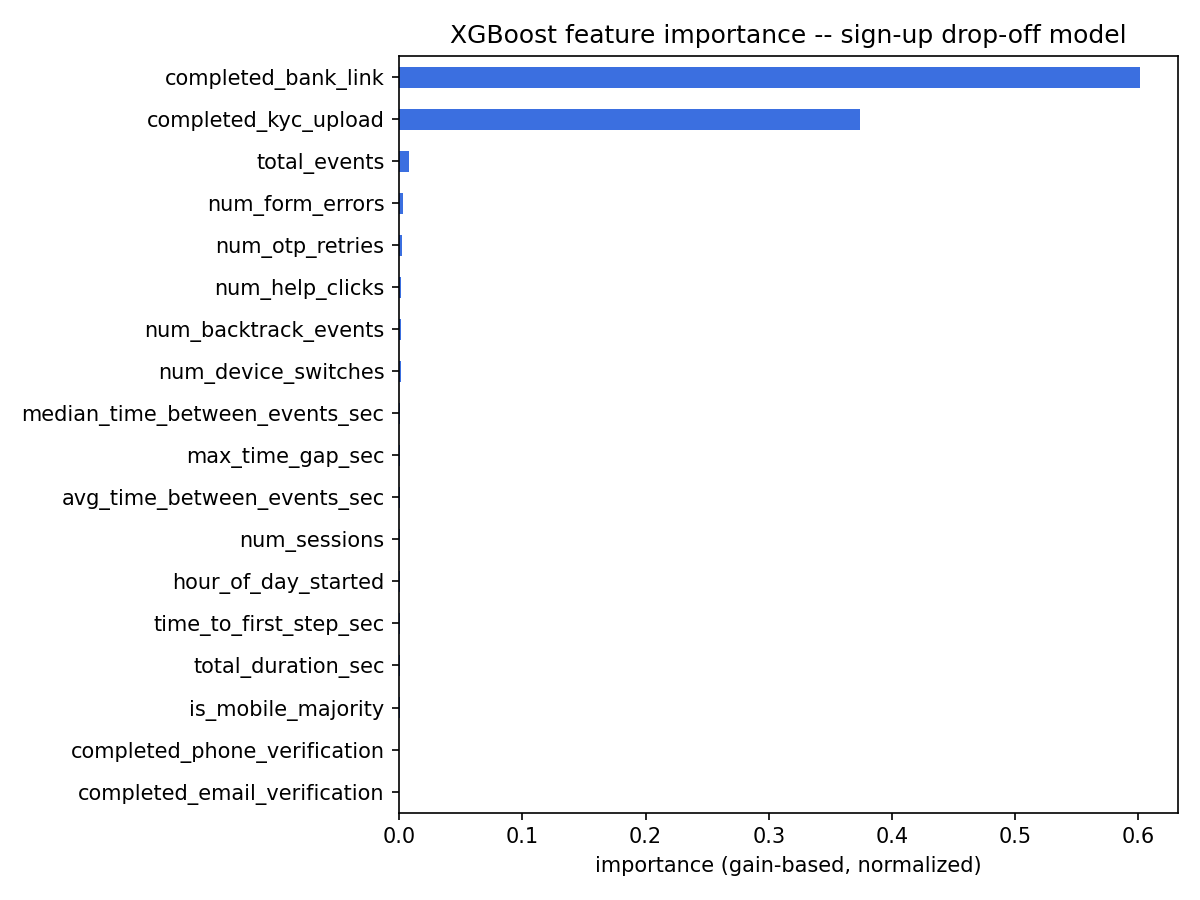

In [21]:
from IPython.display import Image, display
display(Image(filename="/content/fintech_signup_etl/artifacts/feature_importance.png"))


## Notes

- The four `completed_*` checkpoint flags (features 14-17) are strong,
  near-deterministic late-funnel signals, so ROC AUC comes out very high
  (~0.99). For a harder, earlier-warning model — useful if you want to flag
  at-risk users *before* they reach those checkpoints — drop those columns
  from `FEATURE_COLUMNS` in the `src/features.py` cell above and re-run
  step 5c/5d.
- To re-run with a different dataset size/seed without reinstalling
  anything, edit `SIGNUP_N_USERS` / `SIGNUP_RANDOM_SEED` in the `.env` cell
  (step 4) and re-run from step 5a.
- Artifacts (`xgb_dropoff_model.joblib`, `metrics.json`,
  `feature_importance.csv/.png`) are written to
  `/content/fintech_signup_etl/artifacts/` — download them via the Colab
  Files pane before the runtime is recycled if you want to keep them.